# ARIMA Visualization

## Install libraries

In [1]:
!pip install -r ../../requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import libraries

In [2]:
import os
import sys
import pandas as pd
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger, LogType
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Helper functions

In [3]:
def auto_convert(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        # Dates
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")

        # Codes
        elif "code" in col.lower():
            df[col] = df[col].astype("string")

        # Market IDs
        elif "market_id" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        # OHLC
        elif col.lower() in ["open", "high", "low", "close"]:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

        # Volume
        elif "volume" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    return df

## Initialize the Logger

In [4]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [5]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [6]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [7]:
stock_code = "PLX"
value_column_name = "close"

## Load data

In [8]:
arima_model.connect_to_database(database_name=os.getenv("BRONZE_POSTGRES_DATABASE"))

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [9]:
df = arima_model.select(
    schema_name="enterprise",
    table_name="daily_price",
    conditions=[
        Condition(
            column="code",
            operator=SqlOperator.EQUAL_TO,
            value=stock_code,
            data_type=DataType.VARCHAR,
        )
    ],
    order_by=["date"],
)
df = auto_convert(df)
df

,date,code,market_id,open,high,low,close,volume
0,2017-04-21,PLX,1,36.2186,36.2186,32.1632,34.1939,4820970
1,2017-04-24,PLX,1,34.1909,34.6104,33.5616,33.8442,1757390
2,2017-04-25,PLX,1,33.6315,33.8413,31.4990,31.5716,2533550
3,2017-04-26,PLX,1,30.1355,31.1144,30.1355,30.8374,1743790
4,2017-04-27,PLX,1,30.8347,32.0933,30.8347,32.0961,825430
...,...,...,...,...,...,...,...,...
2070,2025-08-06,PLX,1,36.8000,37.6000,36.7000,37.4500,2980400
2071,2025-08-07,PLX,1,37.5000,37.5500,37.0000,37.1000,2324500
2072,2025-08-08,PLX,1,37.1000,38.5000,37.1000,38.2000,6375200
2073,2025-08-11,PLX,1,38.2500,38.5000,37.6500,37.9500,2344600


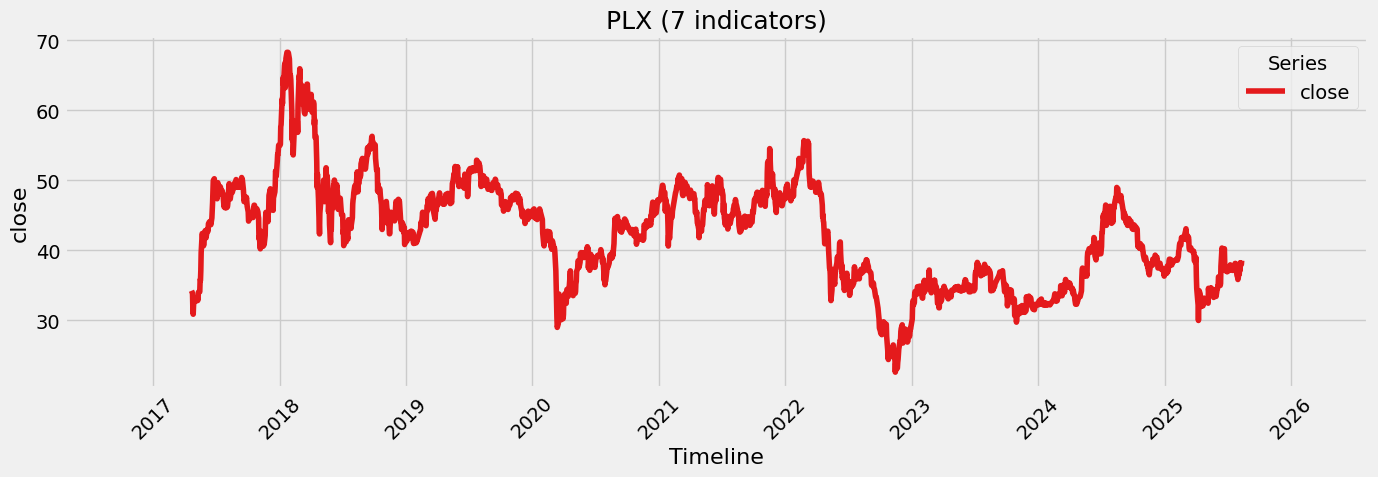

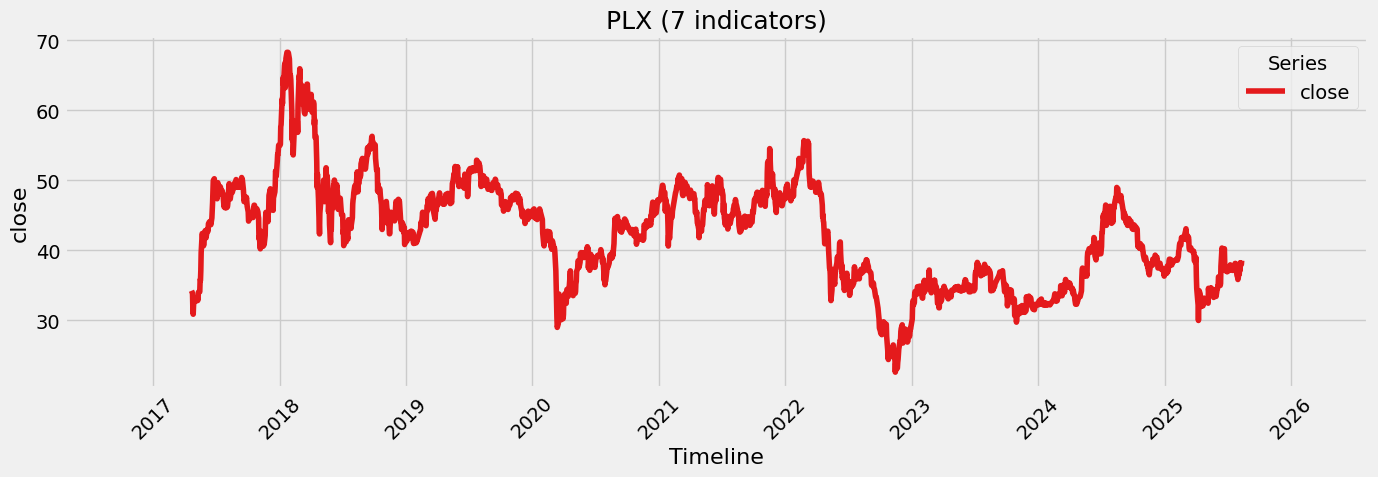

In [10]:
my_visualizer.plot_lines_chart(
    df,
    x_column="date",
    y_columns=[value_column_name],
    title="PLX",
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name="PLX",
    marker=None,
)

## Divide data into train and test

In [11]:
train = df.iloc[: -int(len(df) * 0.2)]
test = df.iloc[-int(len(df) * 0.2) :]

In [12]:
train

,date,code,market_id,open,high,low,close,volume
0,2017-04-21,PLX,1,36.2186,36.2186,32.1632,34.1939,4820970
1,2017-04-24,PLX,1,34.1909,34.6104,33.5616,33.8442,1757390
2,2017-04-25,PLX,1,33.6315,33.8413,31.4990,31.5716,2533550
3,2017-04-26,PLX,1,30.1355,31.1144,30.1355,30.8374,1743790
4,2017-04-27,PLX,1,30.8347,32.0933,30.8347,32.0961,825430
...,...,...,...,...,...,...,...,...
1655,2023-12-01,PLX,1,32.6851,33.3370,32.4058,32.7789,923200
1656,2023-12-04,PLX,1,33.2438,33.3370,32.7782,33.0582,934700
1657,2023-12-05,PLX,1,32.8248,33.7560,32.8248,33.1048,884600
1658,2023-12-06,PLX,1,32.9179,33.4766,32.9179,33.4307,720700


In [13]:
test

,date,code,market_id,open,high,low,close,volume
1660,2023-12-08,PLX,1,32.7317,33.1973,32.6851,33.1979,629600
1661,2023-12-11,PLX,1,33.4301,33.4301,32.7782,33.1979,371900
1662,2023-12-12,PLX,1,33.1973,33.2438,32.6851,33.0117,547300
1663,2023-12-13,PLX,1,32.9645,33.0576,32.3126,32.3133,939000
1664,2023-12-14,PLX,1,32.5920,32.5920,31.7539,31.9873,441400
...,...,...,...,...,...,...,...,...
2070,2025-08-06,PLX,1,36.8000,37.6000,36.7000,37.4500,2980400
2071,2025-08-07,PLX,1,37.5000,37.5500,37.0000,37.1000,2324500
2072,2025-08-08,PLX,1,37.1000,38.5000,37.1000,38.2000,6375200
2073,2025-08-11,PLX,1,38.2500,38.5000,37.6500,37.9500,2344600


## Fit the model

In [ ]:
arima_model.fit(
    series=train[value_column_name], max_p=30, max_d=2, max_q=30, criterion="bic", model_suffix="PLX"
)

Searching ARIMA orders (parallelized):   0%|          | 0/2882 [00:00<?, ?it/s]

Searching ARIMA orders (parallelized):   1%|          | 24/2882 [00:28<1:28:29,  1.86s/it]

In [ ]:
arima_model.get_order()

(0, 1, 0)

## Forecast

In [ ]:
forecast = arima_model.forecast(steps=len(test))  # next 12 periods

In [ ]:
forecast

1660    32.7323
1661    32.7323
1662    32.7323
1663    32.7323
1664    32.7323
         ...   
2070    32.7323
2071    32.7323
2072    32.7323
2073    32.7323
2074    32.7323
Name: forecast, Length: 415, dtype: float64

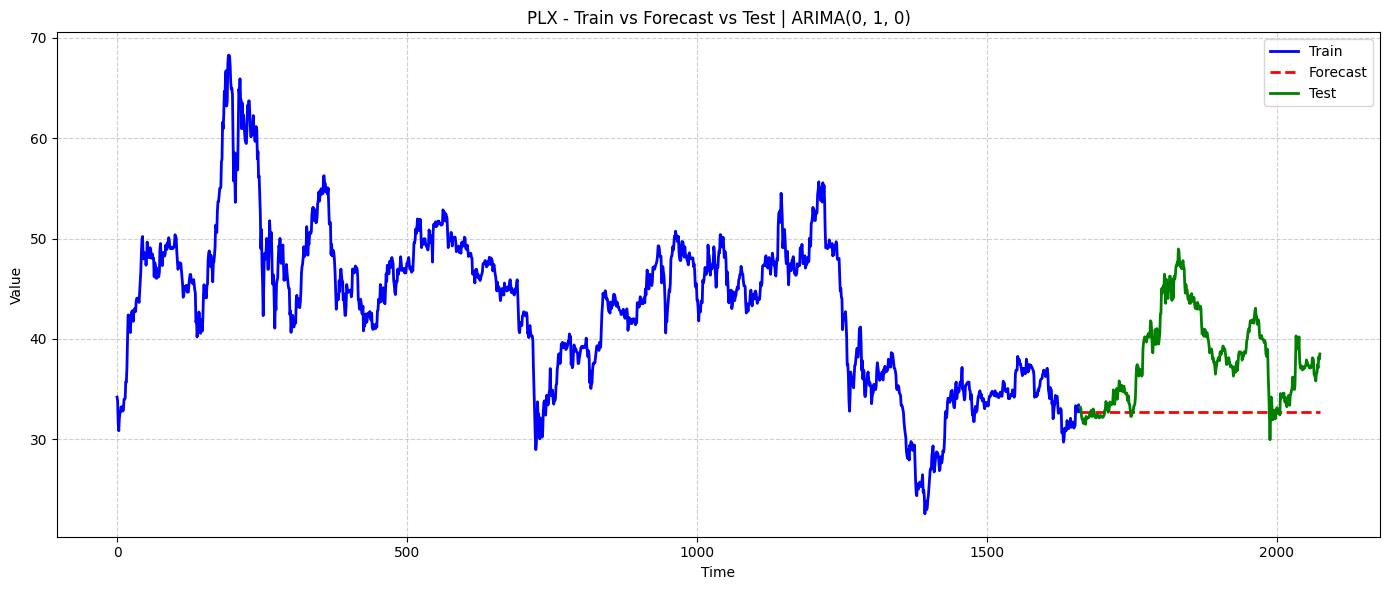

In [ ]:
arima_model.plot_forecast(
    steps=len(test),
    test=test[value_column_name],
    title="PLX - Train vs Forecast vs Test",
)